In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

In [2]:
if 'nav' not in globals():
    nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

if 'fund_master' not in globals():
    fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")

if 'benchmark' not in globals():
    benchmark = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [3]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

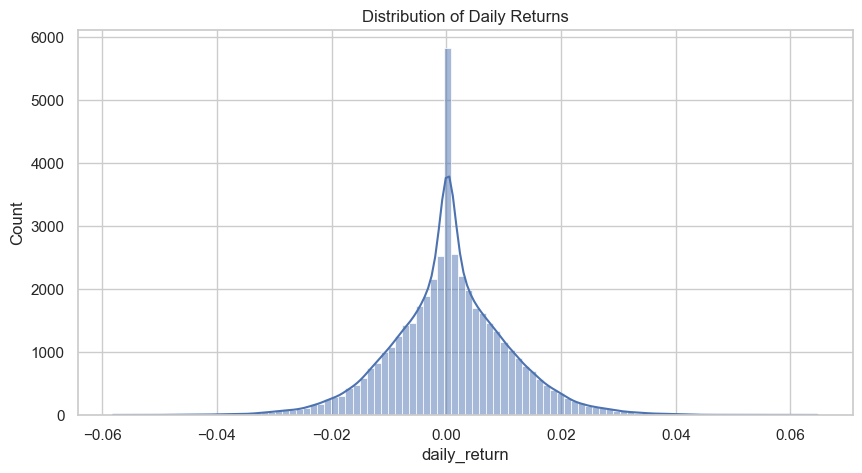

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [5]:
def calculate_cagr(df, years):
    days = years * 252

    results = []

    for code, group in df.groupby('amfi_code'):

        group = group.sort_values('date')

        if len(group) >= days:

            start = group.iloc[-days]['nav']
            end = group.iloc[-1]['nav']

            cagr = (end/start)**(1/years) - 1

            results.append([code, cagr])

    return pd.DataFrame(
        results,
        columns=['amfi_code',f'CAGR_{years}Y']
    )

In [6]:
cagr_1 = calculate_cagr(nav,1)
cagr_3 = calculate_cagr(nav,3)
cagr_5 = calculate_cagr(nav,5)

In [7]:
cagr_table = (
    cagr_1
    .merge(cagr_3,on='amfi_code',how='outer')
    .merge(cagr_5,on='amfi_code',how='outer')
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [8]:
RF = 0.065
sharpe = []

for code, group in nav.groupby('amfi_code'):

    ret = group['daily_return'].dropna()

    if len(ret)>0:

        annual_return = ret.mean()*252
        annual_vol = ret.std()*np.sqrt(252)

        ratio = (
            (annual_return-RF)
            / annual_vol
        )

        sharpe.append([code,ratio])

sharpe_df = pd.DataFrame(
    sharpe,
    columns=['amfi_code','Sharpe']
)

sharpe_df = sharpe_df.sort_values(
    'Sharpe',
    ascending=False
)

In [9]:
sortino = []

for code, group in nav.groupby('amfi_code'):

    ret = group['daily_return'].dropna()

    downside = ret[ret<0]

    if len(downside)>0:

        annual_return = ret.mean()*252

        downside_std = (
            downside.std()
            *np.sqrt(252)
        )

        ratio = (
            (annual_return-RF)
            / downside_std
        )

        sortino.append([code,ratio])

sortino_df = pd.DataFrame(
    sortino,
    columns=['amfi_code','Sortino']
)

In [10]:
benchmark.head()
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [11]:
n100 = benchmark[
    benchmark['close_value']=="Nifty 100"
].copy()

In [12]:
n100 = n100.sort_values('date')

n100['benchmark_return'] = (
    n100['close_value']
    .pct_change()
)

In [13]:
alpha_beta=[]

for code, group in nav.groupby('amfi_code'):

    merged = pd.merge(
        group[['date','daily_return']],
        n100[['date','benchmark_return']],
        on='date'
    ).dropna()

    if len(merged)>50:

        slope, intercept, *_ = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept*252
        beta = slope

        alpha_beta.append(
            [code,alpha,beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'Alpha',
        'Beta'
    ]
)

alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [14]:
drawdowns=[]

for code, group in nav.groupby('amfi_code'):

    group=group.sort_values('date')

    running_max = group['nav'].cummax()

    dd = (
        group['nav']
        /running_max
        -1
    )

    drawdowns.append([
        code,
        dd.min()
    ])

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        'amfi_code',
        'Max_Drawdown'
    ]
)

In [15]:
score = (
    cagr_table
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
    .merge(
        fund_master[
            ['amfi_code','expense_ratio_pct']
        ]
    )
)

In [16]:
score['ret_rank'] = score['CAGR_3Y'].rank(pct=True)

score['sharpe_rank'] = score['Sharpe'].rank(pct=True)

score['alpha_rank'] = score['Alpha'].rank(pct=True)

score['expense_rank'] = (
    score['expense_ratio_pct']
    .rank(pct=True,ascending=False)
)

score['dd_rank'] = (
    score['Max_Drawdown']
    .rank(pct=True,ascending=False)
)

In [17]:
score['Fund_Score'] = (
      score['ret_rank']*30
    + score['sharpe_rank']*25
    + score['alpha_rank']*20
    + score['expense_rank']*15
    + score['dd_rank']*10
)

score['Fund_Score'] = score[
    'Fund_Score'
].round(2)

score = score.sort_values(
    'Fund_Score',
    ascending=False
)

score.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [18]:
print(score.shape)
score.head()

(0, 15)


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,ret_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,Fund_Score


In [19]:
top5 = score.head(5)['amfi_code']

print(top5)
print(type(top5))

Series([], Name: amfi_code, dtype: int64)
<class 'pandas.core.series.Series'>


In [20]:
print(cagr_table.shape)
cagr_table.head()

(40, 4)


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [21]:
print(sharpe_df.shape)
sharpe_df.head()

(40, 2)


,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [22]:
print(alpha_beta_df.shape)
alpha_beta_df.head()
print(drawdown_df.shape)
drawdown_df.head()

(0, 3)
(40, 2)


,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
# Ensure dates are datetime
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

# NIFTY100 benchmark
n100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()

# Benchmark returns
n100 = n100.sort_values('date')
n100['benchmark_return'] = n100['close_value'].pct_change()

alpha_beta = []

for code, grp in nav.groupby('amfi_code'):

    merged = pd.merge(
        grp[['date', 'daily_return']],
        n100[['date', 'benchmark_return']],
        on='date'
    ).dropna()

    if len(merged) > 30:

        beta, alpha, *_ = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha_beta.append([
            code,
            alpha * 252,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=['amfi_code', 'Alpha', 'Beta']
)

print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [24]:
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

In [25]:
score = (
    cagr_table
    .merge(sharpe_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
    .merge(
        fund_master[['amfi_code', 'expense_ratio_pct']],
        on='amfi_code'
    )
)

In [26]:
nav['amfi_code'] = nav['amfi_code'].astype(str)
fund_master['amfi_code'] = fund_master['amfi_code'].astype(str)
alpha_beta_df['amfi_code'] = alpha_beta_df['amfi_code'].astype(str)
sharpe_df['amfi_code'] = sharpe_df['amfi_code'].astype(str)
drawdown_df['amfi_code'] = drawdown_df['amfi_code'].astype(str)
cagr_table['amfi_code'] = cagr_table['amfi_code'].astype(str)

In [27]:
score = (
    cagr_table
    .merge(sharpe_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
    .merge(
        fund_master[['amfi_code', 'expense_ratio_pct']],
        on='amfi_code'
    )
)

In [28]:
score['ret_rank'] = score['CAGR_3Y'].rank(pct=True)
score['sharpe_rank'] = score['Sharpe'].rank(pct=True)
score['alpha_rank'] = score['Alpha'].rank(pct=True)

score['expense_rank'] = score['expense_ratio_pct'].rank(
    pct=True,
    ascending=False
)

score['dd_rank'] = score['Max_Drawdown'].rank(
    pct=True,
    ascending=False
)

score['Fund_Score'] = (
      score['ret_rank'] * 30
    + score['sharpe_rank'] * 25
    + score['alpha_rank'] * 20
    + score['expense_rank'] * 15
    + score['dd_rank'] * 10
).round(2)

score = score.sort_values(
    'Fund_Score',
    ascending=False
)

score.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,ret_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,Fund_Score
25,120505,0.303534,0.302065,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.65,0.625,84.50
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,0.975,0.850,0.875,0.60,0.500,82.00
16,119094,0.309182,0.360660,NaN,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.60,0.700,80.75
21,119598,0.845322,0.278144,NaN,0.945308,0.303370,-0.023196,-0.287060,1.43,0.850,0.675,1.000,0.50,0.900,78.88
34,148567,0.145807,0.312786,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,0.925,1.000,0.850,0.45,0.200,78.50


In [29]:
score.to_csv("fund_scorecard.csv", index=False)

In [30]:
top5 = score.head(5)['amfi_code'].astype(str)

In [31]:
comparison = []

for code in top5:
    temp = nav[nav['amfi_code'].astype(str) == code].copy()

    temp = temp.sort_values('date')

    temp['normalized'] = (
        temp['nav'] / temp['nav'].iloc[0]
    ) * 100

    comparison.append(temp)

comparison = pd.concat(comparison)

In [32]:
fig = px.line(
    comparison,
    x='date',
    y='normalized',
    color='amfi_code',
    title='Top 5 Funds vs Benchmark'
)

fig.show()

fig.write_image("benchmark_comparison.png")

In [33]:
print(alpha_beta_df.shape)
print(score.shape)
print(score[['amfi_code', 'Fund_Score']].head())

(40, 3)
(40, 15)
   amfi_code  Fund_Score
25    120505       84.50
2     100033       82.00
16    119094       80.75
21    119598       78.88
34    148567       78.50
